In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
import pandas as pd

# Example dataset with multiple countries and dates
data = {
    "Date": [
        "2020-03-01", "2020-03-02", "2020-03-03",   # USA
        "2020-03-01", "2020-03-02", "2020-03-03",   # India
        "2020-03-01", "2020-03-02", "2020-03-03"    # Brazil
    ],
    "Country": [
        "USA", "USA", "USA",
        "India", "India", "India",
        "Brazil", "Brazil", "Brazil"
    ],
    "Cumulative Total Cases": [100, 150, 220, 50, 80, 120, 30, 60, 100],
    "Daily New Cases": [100, 50, 70, 50, 30, 40, 30, 30, 40],
    "Active Cases": [90, 130, 190, 45, 70, 110, 28, 55, 95],
    "Cumulative Total Deaths": [10, 20, 30, 5, 10, 15, 2, 5, 8],
    "Daily New Deaths": [10, 10, 10, 5, 5, 5, 2, 3, 3]
}

df = worldometer_coronavirus_daily_data = pd.DataFrame(data)

df


,Date,Country,Cumulative Total Cases,Daily New Cases,Active Cases,Cumulative Total Deaths,Daily New Deaths
0,2020-03-01,USA,100,100,90,10,10
1,2020-03-02,USA,150,50,130,20,10
2,2020-03-03,USA,220,70,190,30,10
3,2020-03-01,India,50,50,45,5,5
4,2020-03-02,India,80,30,70,10,5
5,2020-03-03,India,120,40,110,15,5
6,2020-03-01,Brazil,30,30,28,2,2
7,2020-03-02,Brazil,60,30,55,5,3
8,2020-03-03,Brazil,100,40,95,8,3


In [43]:
df.to_csv(' worldometer_coronavirus_daily_data.csv')

In [19]:
df.head()

,Date,Country,Cumulative Total Cases,Daily New Cases,Active Cases,Cumulative Total Deaths,Daily New Deaths
0,2020-03-01,USA,100,100,90,10,10
1,2020-03-02,USA,150,50,130,20,10
2,2020-03-03,USA,220,70,190,30,10
3,2020-03-01,India,50,50,45,5,5
4,2020-03-02,India,80,30,70,10,5


In [23]:
df.isnull().sum()
df.fillna(0,inplace=True)
df['date'] = pd.to_datetime(df['Date'])

In [25]:
df.describe()
df['Country'].value_counts().head(10)

Country
USA       3
India     3
Brazil    3
Name: count, dtype: int64

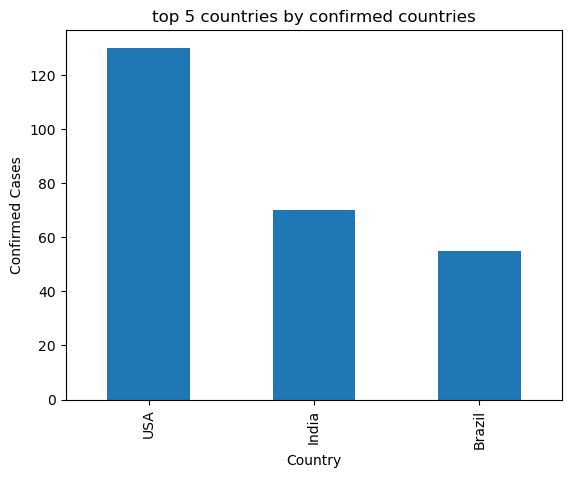

In [30]:
top_countries = df[df['Date'] == '2020-03-02'].groupby('Country')['Active Cases'].sum().nlargest(5)
top_countries.plot(kind='bar',title='top 5 countries by confirmed countries')
plt.ylabel('Confirmed Cases')
plt.show()

In [36]:
df['Cumulative Total Deaths'] = df['Cumulative Total Deaths']/df['Active Cases']
highest_death_rate =df.groupby('Country')['Cumulative Total Deaths'].mean().sort_values(ascending=False)
highest_death_rate.head()

Country
Brazil    4.239255e-08
India     1.132581e-08
USA       7.844418e-10
Name: Cumulative Total Deaths, dtype: float64

In [44]:
df.to_csv('covid19_analysis_cleaned.csv',index=False)